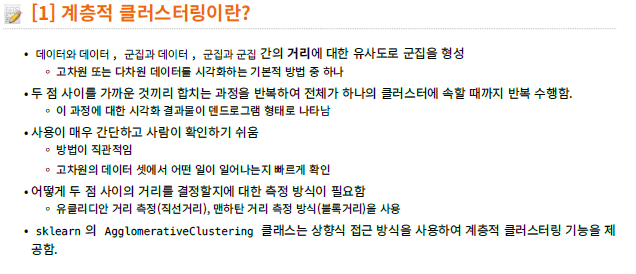
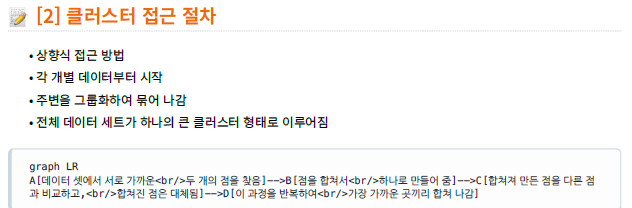


### 패키지 불러오기

In [4]:
# -------------------------------
# 사용자 정의 모듈
# -------------------------------
from hossam import load_data, my_dpi


# -------------------------------
# 데이터 처리
# -------------------------------
import numpy as np
from pandas import DataFrame


# -------------------------------
# 시각화
# -------------------------------
import seaborn as sb
from matplotlib import pyplot as plt


# -------------------------------
# 머신러닝 / 평가 지표
# -------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import AgglomerativeClustering

# -------------------------------
# 기하 / 계층적 군집
# -------------------------------
from scipy.spatial import ConvexHull
from scipy.cluster.hierarchy import dendrogram, linkage

# -------------------------------
# 덴드로그램 구현 함수
# -------------------------------
from scipy.cluster.hierarchy import dendrogram

ImportError: cannot import name 'load_data' from 'hossam' (unknown location)

In [ ]:

import hossam
print(hossam.__file__)


c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\hossam\__init__.py


In [ ]:
dir(hossam)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_init',
 '_init_korean_font',
 'as_file',
 'files',
 'fm',
 'hs_classroom',
 'hs_gis',
 'hs_plot',
 'hs_prep',
 'hs_stats',
 'hs_timeserise',
 'hs_util',
 'load_data',
 'load_info',
 'my_dpi',
 'plt',
 'sys',
 'version',
 'warnings']

In [ ]:
import hossam
hasattr(hossam, "visualize_silhouette")

False

In [ ]:
import hossam as core

'visualize_silhouette' in dir(core)




NameError: name 'visualize' is not defined

In [ ]:

dir('hs_util')

['__add__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmod__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'capitalize',
 'casefold',
 'center',
 'count',
 'encode',
 'endswith',
 'expandtabs',
 'find',
 'format',
 'format_map',
 'index',
 'isalnum',
 'isalpha',
 'isascii',
 'isdecimal',
 'isdigit',
 'isidentifier',
 'islower',
 'isnumeric',
 'isprintable',
 'isspace',
 'istitle',
 'isupper',
 'join',
 'ljust',
 'lower',
 'lstrip',
 'maketrans',
 'partition',
 'removeprefix',
 'removesuffix',
 'replace',
 'rfind',
 'rindex',
 'rjust',
 'rpartition',
 'rsplit',
 'rstrip',
 'split',
 'splitlines',
 'startswith',
 'stri

In [ ]:
import hossam
dir(hossam)
print(hossam.__file__)


c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\hossam\__init__.py


In [ ]:
from hossam import visualization
dir(visualize_silhouette)


ImportError: cannot import name 'visualization' from 'hossam' (c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\hossam\__init__.py)

### 데이터 불러오기

In [6]:
origin = load_data("game_usage")
origin.head()

NameError: name 'load_data' is not defined

### 데이터 스케일링

In [2]:

scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(origin), columns=origin.columns)
sdf

NameError: name 'StandardScaler' is not defined

### 군집수행

In [3]:
# -------------------------------
# Agglomerative Clustering 설정
# -------------------------------
# estimator = AgglomerativeClustering(
#     n_clusters=4,
#     # 노드 간 거리 계산값 도출 여부 (시각화를 위해서는 필수 적용)
#     compute_distances=True,
# )

estimator = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=5,
    # 노드 간 거리 계산값 도출 여부 (시각화를 위해서는 필수 적용)
    compute_distances=True,
)


# -------------------------------
# 모델 학습
# -------------------------------
estimator.fit(sdf)


# -------------------------------
# 결과 정리
# -------------------------------
result_df = sdf.copy()
result_df["cluster"] = estimator.labels_

result_df.head(10)


NameError: name 'AgglomerativeClustering' is not defined

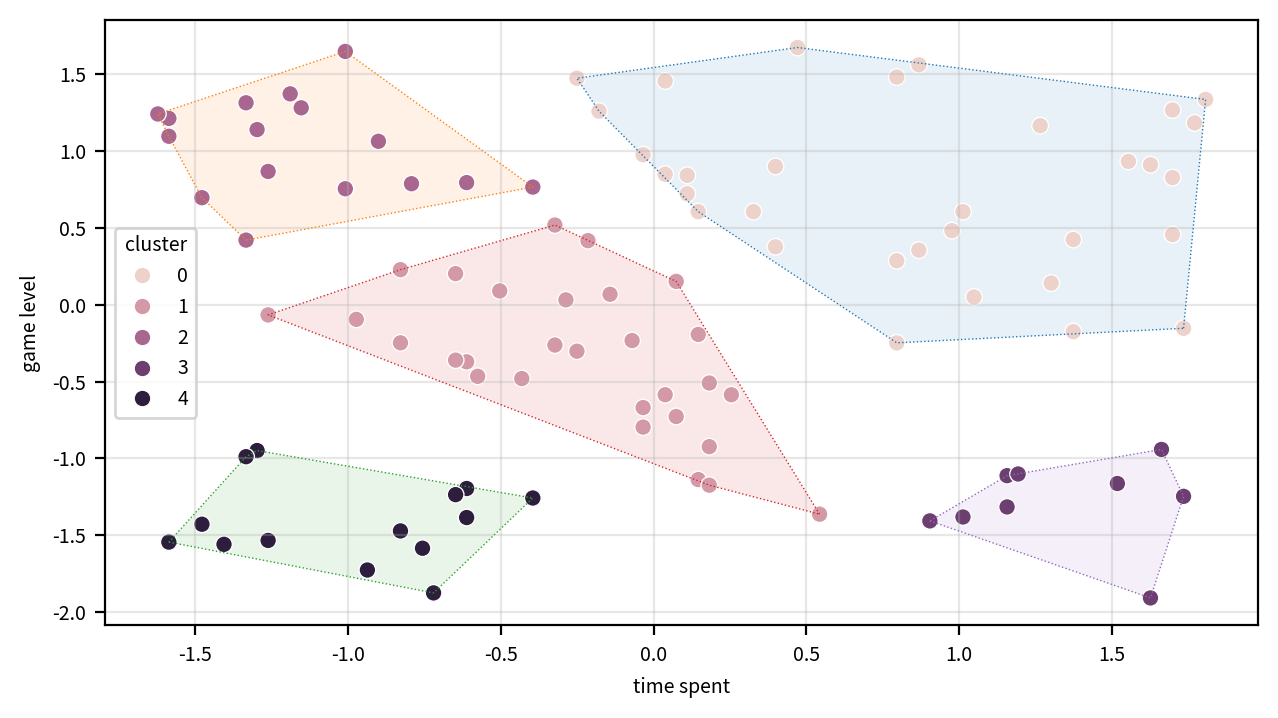

In [ ]:
# -------------------------------
# 시각화용 데이터 설정
# -------------------------------
vdf = result_df.copy()

hue_field = "cluster"
x_field = "time spent"
y_field = "game level"


# -------------------------------
# 그래프 초기화
# -------------------------------
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 군집별 Convex Hull
# -------------------------------
for c in vdf[hue_field].unique():

    # 군집별 데이터 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        hull = ConvexHull(df_c)

        # 마지막 점과 첫 점 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 전체 데이터 산점도
# -------------------------------
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


In [ ]:
estimator.n_clusters_

np.int64(5)

In [ ]:
visualize_silhouette(estimator=estimator, data=result_df)

NameError: name 'visualize_silhouette' is not defined

In [1]:
data = dendrogram(estimator)
data

NameError: name 'dendrogram' is not defined

### 1️⃣ Dendrogram (p = 30)

In [3]:
# -------------------------------
# Figure 설정
# -------------------------------
figsize = (1500 / my_dpi, 800 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# Dendrogram
# -------------------------------
dendrogram(
    data,
    ax=ax,
    p=30,
    truncate_mode="lastp",
    leaf_rotation=0,
    leaf_font_size=8,
    count_sort="ascending",
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.set_title("Dendrogram", fontsize=12, pad=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


NameError: name 'my_dpi' is not defined

### 2️⃣ Dendrogram (p = 100)

In [4]:
# -------------------------------
# Figure 설정
# -------------------------------
figsize = (3500 / my_dpi, 1000 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# Dendrogram
# -------------------------------
dendrogram(
    data,
    ax=ax,
    p=100,
    truncate_mode="lastp",
    leaf_rotation=0,
    leaf_font_size=8,
    count_sort="ascending",
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.set_title("Dendrogram", fontsize=12, pad=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


NameError: name 'my_dpi' is not defined